In [1]:
# Predictive Analytics Using Historical Data

In [2]:
#Problem Statement 
## The Objective of this project is to analyze historical sales data and build a predictive model that 
## can forecast future revenue based on various business factors such as sales, price, marketing spend 
## and customer count.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_excel(r"C:\Users\saiki\Desktop\Project1A\Predictive Analysis Using Historial Project\Predictive_Analysis_Raw_Data.xlsx")

In [5]:
df.head()

,Date,Product_ID,Product_Category,Sales,Revenue,Price,Quantity_Sold,Marketing_Spend,Customer_Count,Profit
0,2025-10-16,P535,Food,272.0,29842.0,423.48,23.0,2945.0,286.0,13146.0
1,2024-04-24,P217,Electronics,461.0,24015.0,421.12,100.0,9591.0,15.0,17458.0
2,2024-01-26,P657,Furniture,264.0,48345.0,438.86,37.0,8952.0,748.0,12674.0
3,2024-10-08,P330,Electronics,248.0,14962.0,94.66,46.0,2216.0,439.0,13750.0
4,2024-09-07,P763,Books,60.0,42161.0,53.31,42.0,6440.0,754.0,10395.0


In [6]:
df.tail()

,Date,Product_ID,Product_Category,Sales,Revenue,Price,Quantity_Sold,Marketing_Spend,Customer_Count,Profit
995,2024-10-17,P278,Furniture,500.0,1746.0,7.39,23.0,232.0,652.0,919.0
996,2025-06-03,P943,Food,188.0,12491.0,473.75,18.0,864.0,994.0,406.0
997,2024-04-04,P334,Electronics,345.0,13363.0,390.58,57.0,5047.0,86.0,3002.0
998,2024-04-15,P649,Furniture,376.0,35975.0,163.86,8.0,4623.0,435.0,15240.0
999,2024-09-27,P719,Books,298.0,32177.0,434.35,58.0,8015.0,113.0,145.0


In [7]:
df.shape

(1000, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              981 non-null    datetime64[ns]
 1   Product_ID        979 non-null    object        
 2   Product_Category  980 non-null    object        
 3   Sales             981 non-null    float64       
 4   Revenue           981 non-null    float64       
 5   Price             979 non-null    float64       
 6   Quantity_Sold     982 non-null    float64       
 7   Marketing_Spend   980 non-null    float64       
 8   Customer_Count    979 non-null    float64       
 9   Profit            982 non-null    float64       
dtypes: datetime64[ns](1), float64(7), object(2)
memory usage: 78.3+ KB


In [9]:
df.describe()

,Date,Sales,Revenue,Price,Quantity_Sold,Marketing_Spend,Customer_Count,Profit
count,981,981.000000,981.000000,979.000000,982.000000,980.000000,979.000000,982.000000
mean,2024-12-30 20:19:48.990825728,253.822630,24906.278287,250.469714,51.285132,4933.143878,496.355465,7740.728106
min,2024-01-01 00:00:00,10.000000,1044.000000,5.080000,1.000000,3.000000,2.000000,-4900.000000
25%,2024-07-08 00:00:00,136.000000,12384.000000,127.970000,26.000000,2317.750000,233.500000,1671.250000
50%,2024-12-25 00:00:00,257.000000,24534.000000,254.430000,51.000000,4971.000000,492.000000,8016.000000
75%,2025-07-05 00:00:00,370.000000,37434.000000,368.705000,77.000000,7534.000000,746.000000,14115.750000
max,2025-12-31 00:00:00,500.000000,49873.000000,499.370000,100.000000,9999.000000,1000.000000,19968.000000
std,NaN,137.914537,14200.090019,141.048639,29.008069,2942.240036,289.982498,7138.039709


In [10]:
df.isnull().sum()

Date                19
Product_ID          21
Product_Category    20
Sales               19
Revenue             19
Price               21
Quantity_Sold       18
Marketing_Spend     20
Customer_Count      21
Profit              18
dtype: int64

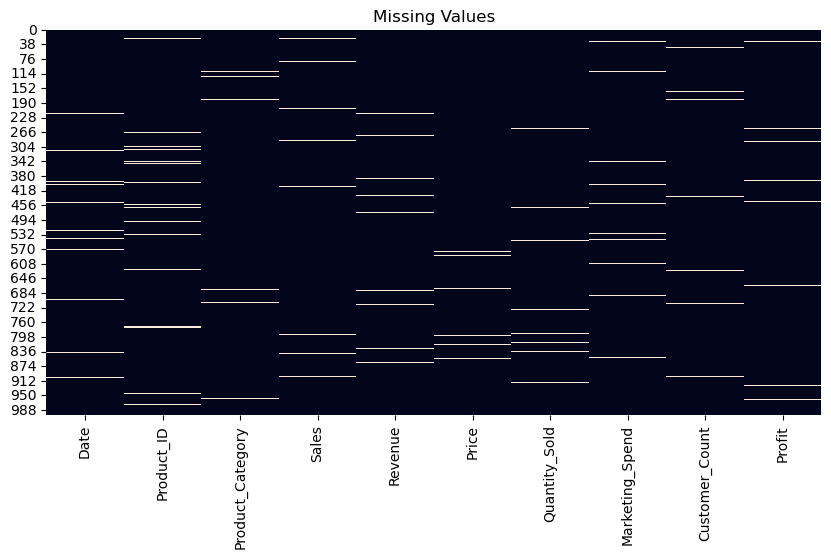

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()

In [12]:
print("Duplicated Rows:",df.duplicated().sum())

Duplicated Rows: 47


In [13]:
df = df.drop_duplicates()

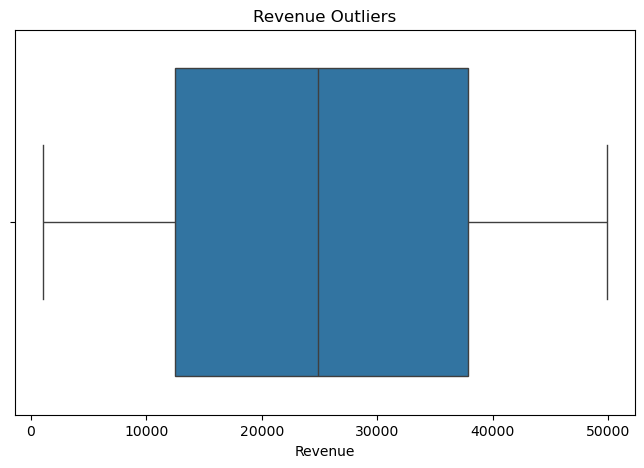

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Revenue"])
plt.title("Revenue Outliers")
plt.show()

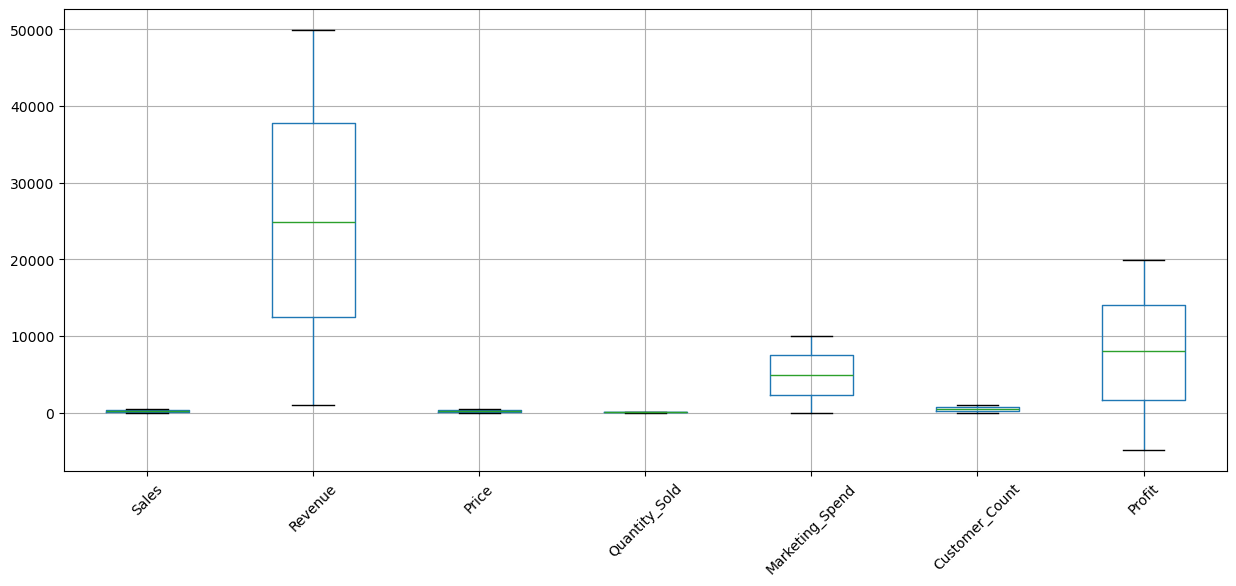

In [15]:
import matplotlib.pyplot as plt

numerical_cols = [
    'Sales',
    'Revenue',
    'Price',
    'Quantity_Sold',
    'Marketing_Spend',
    'Customer_Count',
    'Profit'
]

df[numerical_cols].boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

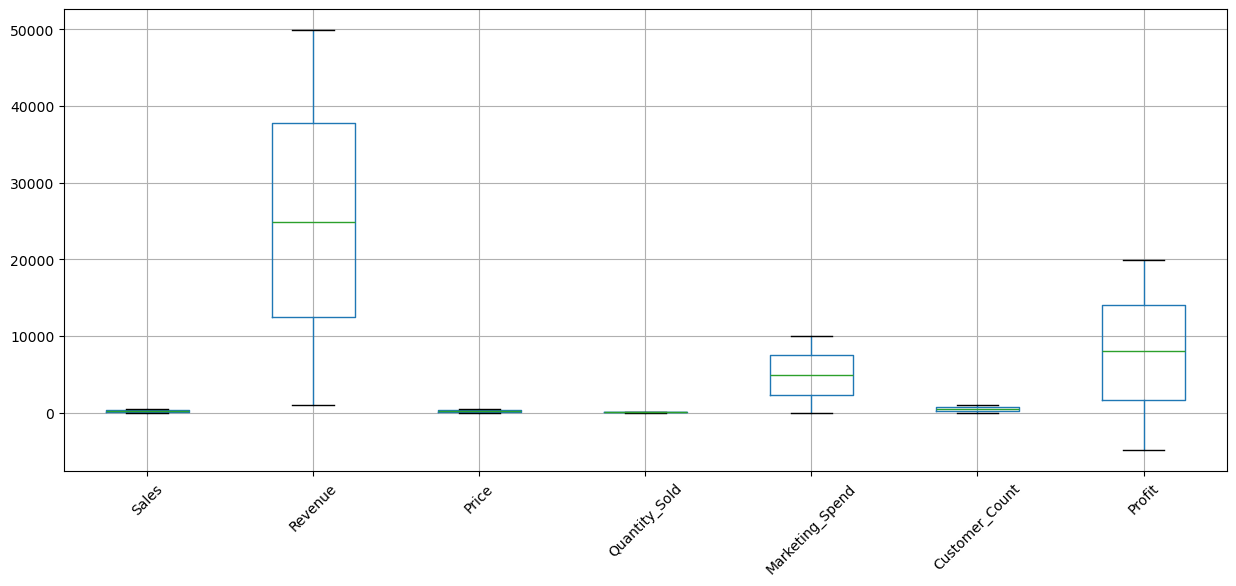

In [16]:
df[numerical_cols].boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [17]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Quarter"] = df["Date"].dt.quarter

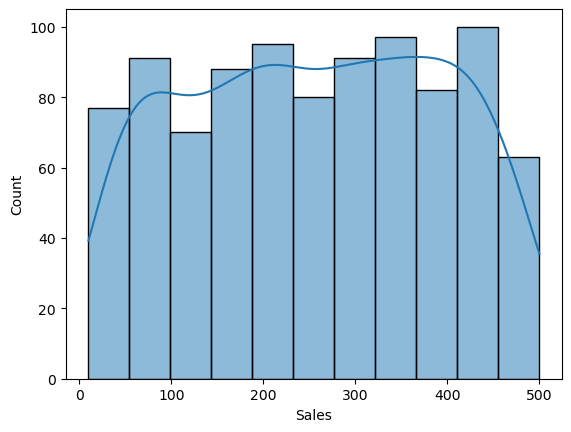

In [18]:
# Sales Distribution
sns.histplot(df["Sales"], kde=True)
plt.show()

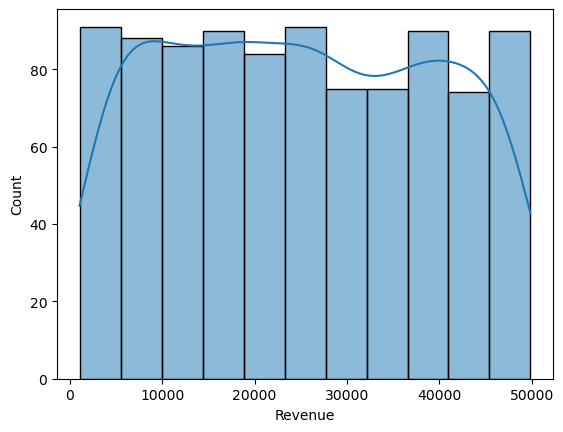

In [19]:
# Revenue Distribution
sns.histplot(df["Revenue"], kde = True)
plt.show()

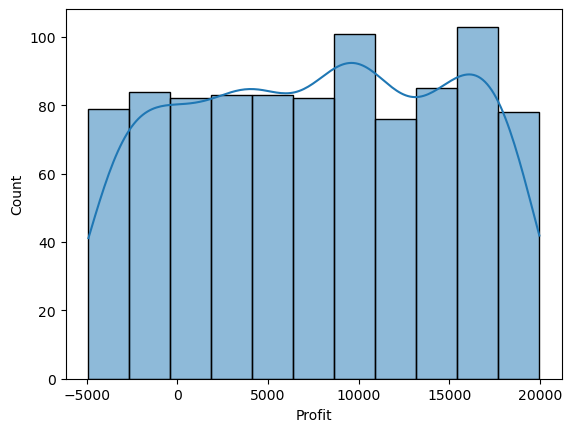

In [20]:
# Profit Distribution
sns.histplot(df["Profit"], kde = True)
plt.show()

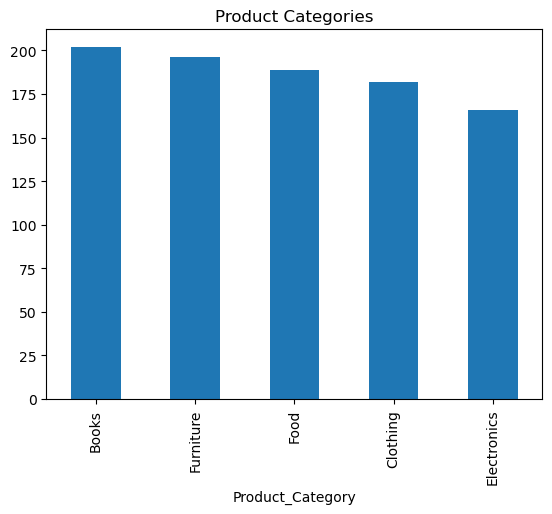

In [21]:
# Top Product Categories
df["Product_Category"].value_counts().plot(kind="bar")
plt.title("Product Categories")
plt.show()

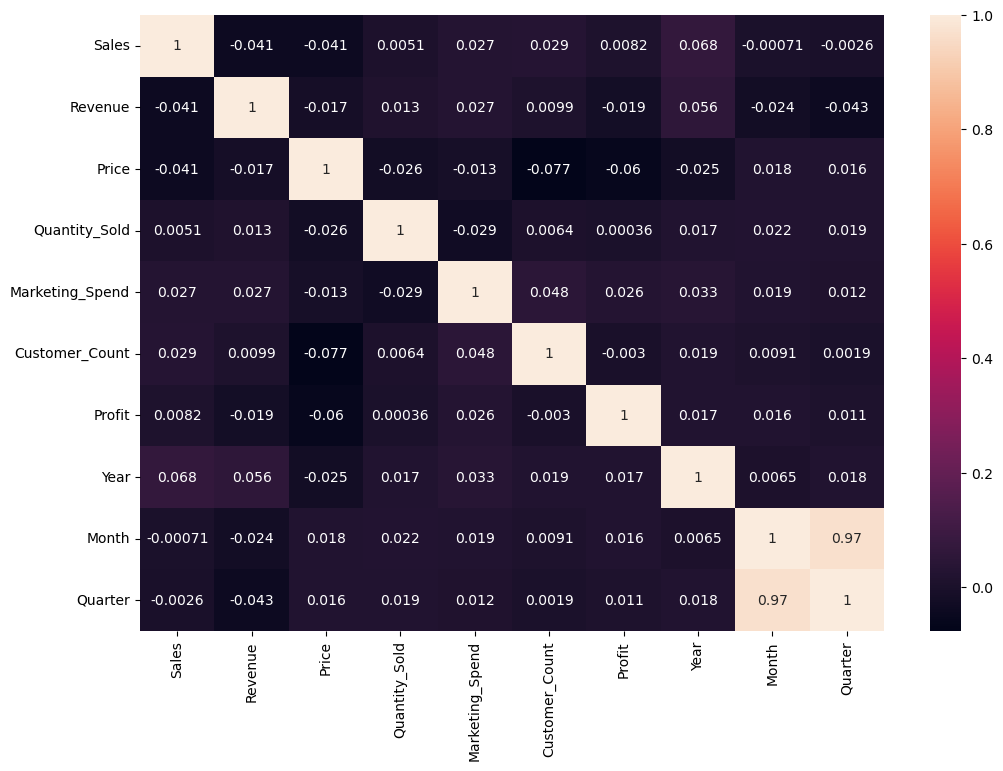

In [22]:
# Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

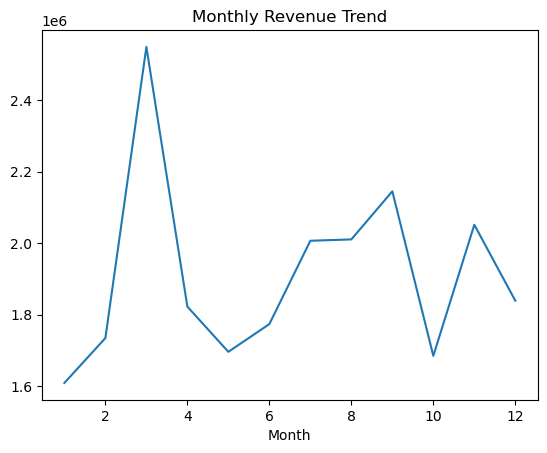

In [23]:
# Revenue Trend Analysis
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
X = df.drop('Revenue',axis=1)
y=df['Revenue']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
print(X.dtypes)

Date                datetime64[ns]
Product_ID                  object
Product_Category            object
Sales                      float64
Price                      float64
Quantity_Sold              float64
Marketing_Spend            float64
Customer_Count             float64
Profit                     float64
Year                       float64
Month                      float64
Quarter                    float64
dtype: object


In [28]:
X = df.drop(['Revenue','Date'],axis =1)

In [29]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

X = df[['Year', 'Month', 'Day', 'Sales']]
y = df['Revenue']

In [30]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()

df['Product_ID'] = le1.fit_transform(df['Product_ID'])
df['Product_Category'] = le2.fit_transform(df['Product_Category'])

In [31]:
# Combine X and y
data = pd.concat([X, y], axis=1)

# Remove rows with any missing values
data = data.dropna()

# Split again
X = data.drop('Revenue', axis=1)
y = data['Revenue']

# Train model
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [32]:
print(model.feature_names_in_)
print(X.columns.tolist())
print(X_test.columns.tolist())

['Year' 'Month' 'Day' 'Sales']
['Year', 'Month', 'Day', 'Sales']
['Date', 'Product_ID', 'Product_Category', 'Sales', 'Price', 'Quantity_Sold', 'Marketing_Spend', 'Customer_Count', 'Profit', 'Year', 'Month', 'Quarter']


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
mask = ~y_test.isna()

y_test_clean = y_test[mask]
y_pred_clean = y_pred[mask]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test_clean, y_pred_clean))
print("RMSE:", np.sqrt(mean_squared_error(y_test_clean, y_pred_clean)))
print("R2:", r2_score(y_test_clean, y_pred_clean))

In [ ]:
y_pred = model.predict(X_test)
# Check for missing values
print(X_test.isnull().sum())

# Fill missing values if any
X_test = X_test.fillna(X_test.mean())

# Predict
y_pred = model.predict(X_test)

print(y_pred[:5])
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(coef_df)

In [ ]:
# Business Insights
## 1. Marketing spend has a positive impact on revenue.
## 2. Higher customer count leads to higher sales.
## 3. Certain product categories generate more profit.
## 4. Revenue trends indicate seasonal patterns.

In [34]:
# Conclusion
## The project successfully cleaned historical business data, analyzed trends, and built a 
## predictive model to forecast revenue. The model can help organizations make data-driven
## decisions regarding sales and marketing strategies.

In [36]:
df = df.dropna()
print(df.isnull().sum())

Date                0
Product_ID          0
Product_Category    0
Sales               0
Revenue             0
Price               0
Quantity_Sold       0
Marketing_Spend     0
Customer_Count      0
Profit              0
Year                0
Month               0
Quarter             0
Day                 0
dtype: int64


In [37]:
# Save cleaned dataset
df.to_csv("cleaned_sales_data.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!
